# 🛡️ PrédiSinistre — Détection de Fraude Assurantielle
## Rendu 1 : Exploration, Data Visualisation & Pre-processing

---

| Champ              | Détail                                              |
|--------------------|-----------------------------------------------------|
| **Cursus**         | Data Scientist — DataScientest                      |
| **Difficulté**     | 6 / 10                                              |
| **Dataset**        | `insurance_claims.csv` (1 000 lignes × 40 colonnes) |
| **Variable cible** | `fraud_reported` (Y = fraude / N = non-fraude)      |
| **Objectif**       | Détecter automatiquement les sinistres frauduleux   |

---

## 📋 Plan du notebook

1. [Imports & Configuration](#1)
2. [Chargement et première inspection](#2)
3. [Analyse univariée](#3)
4. [Visualisation — 6 graphiques commentés](#4)
5. [Nettoyage et préparation du dataset](#5)
6. [Encodage et Feature Engineering](#6)
7. [Export du dataset propre](#7)
8. [Modèles de base (Baseline)](#8)
9. [Interprétation et perspectives](#9)

---
## 1. Imports & Configuration <a id='1'></a>

On importe toutes les bibliothèques nécessaires en une seule cellule, conformément aux bonnes pratiques :
- **pandas / numpy** : manipulation et calcul sur données tabulaires
- **matplotlib / seaborn** : visualisation
- **sklearn** : prétraitement, modèles et évaluation

On fixe également les graines aléatoires (`RANDOM_STATE`) pour garantir la **reproductibilité** des résultats.

In [1]:
# ─────────────────────────────────────────────────────────────────
# BLOC 1 — IMPORTS & CONFIGURATION GLOBALE
# ─────────────────────────────────────────────────────────────────

# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# Prétraitement & sélection de features
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

# Modèles de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier  # modèle naïf de référence

# Métriques d'évaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score
)

# Utilitaires
import warnings
warnings.filterwarnings('ignore')  # masquer les avertissements non critiques

# ── Constantes de configuration ──────────────────────────────────
RANDOM_STATE = 42          # graine pour la reproductibilité
TEST_SIZE    = 0.20        # proportion du jeu de test
DATA_PATH    = 'insurance_claims.csv'  # chemin vers le dataset brut
OUTPUT_PATH  = 'insurance_claims_clean.csv'  # chemin de sortie

# ── Palette de couleurs cohérente dans tout le notebook ──────────
COLOR_NON_FRAUD = '#2E86AB'   # bleu  → sinistres légitimes
COLOR_FRAUD     = '#E84855'   # rouge → sinistres frauduleux
PALETTE_GENERAL = ['#2E86AB', '#E84855', '#3BB273', '#F9C74F', '#9B5DE5']

# ── Style global des graphiques ──────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi'      : 120,
    'font.family'     : 'DejaVu Sans',
    'axes.titlesize'  : 13,
    'axes.labelsize'  : 11,
    'legend.fontsize' : 10,
    'xtick.labelsize' : 9,
    'ytick.labelsize' : 9,
})

print('✅ Imports et configuration terminés.')

✅ Imports et configuration terminés.


---
## 2. Chargement et première inspection du dataset <a id='2'></a>

Cette étape vise à répondre à trois questions fondamentales :
1. **Quelle est la structure du dataset ?** (dimensions, types de colonnes)
2. **Y a-t-il des données manquantes ?** (NaN natifs, valeurs encodées '?')
3. **Quelle est la distribution de la variable cible ?** (déséquilibre de classes)

> 📌 **Règle méthodologique** : on n'effectue AUCUNE transformation à ce stade — on observe uniquement.

In [4]:
# ─────────────────────────────────────────────────────────────────
# BLOC 2.1 — CHARGEMENT DU DATASET
# ─────────────────────────────────────────────────────────────────

df = pd.read_csv("../data/raw/insurance_claims.csv")

# Affichage des dimensions et des premières lignes du dataset
print('=' * 60)
print(f'  Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print('=' * 60)

df.head()

  Dimensions : 1000 lignes × 40 colonnes


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [ ]:
# ─────────────────────────────────────────────────────────────────
# BLOC 2.2 — TYPES ET VALEURS MANQUANTES
# ─────────────────────────────────────────────────────────────────

# Résumé des types de données : distinguer variables numériques / catégorielles
dtype_summary = pd.DataFrame({
    'Type'           : df.dtypes,
    'Valeurs_nulles' : df.isnull().sum(),
    '% Nulles'       : (df.isnull().sum() / len(df) * 100).round(2),
    'Nb_uniques'     : df.nunique(),
})

# Détection des colonnes contenant des '?' (valeurs manquantes masquées)
question_mark_counts = {}
for col in df.select_dtypes(include=['object', 'str']).columns:
    count = (df[col] == '?').sum()
    if count > 0:
        question_mark_counts[col] = count


dtype_summary['Nb_points_interrogation'] = 0
for col, count in question_mark_counts.items():
    dtype_summary.loc[col, 'Nb_points_interrogation'] = count

# Affichage du résumé des types et des valeurs manquantes
print('─── Résumé des colonnes ───────────────────────────────────')
print(dtype_summary.to_string())
print()
print(f'⚠️  Colonnes avec des points d\'interrogation : {list(question_mark_counts.keys())}')

─── Résumé des colonnes ───────────────────────────────────
                                Type  Valeurs_nulles  % Nulles  Nb_uniques  Nb_points_interrogation
months_as_customer             int64               0       0.0         391                        0
age                            int64               0       0.0          46                        0
policy_number                  int64               0       0.0        1000                        0
policy_bind_date                 str               0       0.0         951                        0
policy_state                     str               0       0.0           3                        0
policy_csl                       str               0       0.0           3                        0
policy_deductable              int64               0       0.0           3                        0
policy_annual_premium        float64               0       0.0         991                        0
umbrella_limit                 int64    

In [6]:
# ─────────────────────────────────────────────────────────────────
# BLOC 2.3 — DISTRIBUTION DE LA VARIABLE CIBLE
# ─────────────────────────────────────────────────────────────────

# Comptage et taux par classe
target_counts = df['fraud_reported'].value_counts()
target_pct    = df['fraud_reported'].value_counts(normalize=True) * 100

print('─── Variable cible : fraud_reported ───────────────────────')
print(f'  Non-fraude (N) : {target_counts["N"]:>5} observations  ({target_pct["N"]:.1f} %)')
print(f'  Fraude     (Y) : {target_counts["Y"]:>5} observations  ({target_pct["Y"]:.1f} %)')
print(f'  Ratio déséquilibre : {target_counts["N"] / target_counts["Y"]:.2f}:1')
print()
print('💡 Conclusion : déséquilibre modéré (3:1). On privilégiera')
print('   le ROC-AUC et le F1-score plutôt que l\'accuracy globale.')

─── Variable cible : fraud_reported ───────────────────────
  Non-fraude (N) :   753 observations  (75.3 %)
  Fraude     (Y) :   247 observations  (24.7 %)
  Ratio déséquilibre : 3.05:1

💡 Conclusion : déséquilibre modéré (3:1). On privilégiera
   le ROC-AUC et le F1-score plutôt que l'accuracy globale.


In [7]:
# ─────────────────────────────────────────────────────────────────
# BLOC 2.4 — STATISTIQUES DESCRIPTIVES DES VARIABLES NUMÉRIQUES
# ─────────────────────────────────────────────────────────────────

# describe() donne : count, mean, std, min, quartiles, max
# On transpose pour une meilleure lisibilité
num_stats = df.select_dtypes(include='number').describe().T

# Ajout d'une colonne d'asymétrie (skewness) : >0 = queue à droite, <0 = queue à gauche
num_stats['skewness'] = df.select_dtypes(include='number').skew().round(3)

print('─── Statistiques descriptives — Variables numériques ───────')
num_stats.round(2)

─── Statistiques descriptives — Variables numériques ───────


,count,mean,std,min,25%,50%,75%,max,skewness
months_as_customer,1000.0,203.95,115.11,0.00,115.75,199.5,276.25,479.00,0.36
age,1000.0,38.95,9.14,19.00,32.00,38.0,44.00,64.00,0.48
policy_number,1000.0,546238.65,257063.01,100804.00,335980.25,533135.0,759099.75,999435.00,0.04
policy_deductable,1000.0,1136.00,611.86,500.00,500.00,1000.0,2000.00,2000.00,0.48
policy_annual_premium,1000.0,1256.41,244.17,433.33,1089.61,1257.2,1415.70,2047.59,0.00
umbrella_limit,1000.0,1101000.00,2297406.60,-1000000.00,0.00,0.0,0.00,10000000.00,1.81
insured_zip,1000.0,501214.49,71701.61,430104.00,448404.50,466445.5,603251.00,620962.00,0.82
capital-gains,1000.0,25126.10,27872.19,0.00,0.00,0.0,51025.00,100500.00,0.48
capital-loss,1000.0,-26793.70,28104.10,-111100.00,-51500.00,-23250.0,0.00,0.00,-0.39
incident_hour_of_the_day,1000.0,11.64,6.95,0.00,6.00,12.0,17.00,23.00,-0.04


---
## 3. Analyse univariée des variables catégorielles <a id='3'></a>

Pour chaque variable catégorielle, on examine :
- Le nombre de modalités (cardinalité)
- La fréquence de chaque modalité
- Le **taux de fraude conditionnel** par modalité (lien avec la cible)

> ⚠️ Les colonnes `policy_number`, `insured_zip` et `incident_location` ont une
> cardinalité quasi-maximale (identifiants uniques) : elles seront supprimées lors
> du nettoyage car elles ne peuvent pas généraliser.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# BLOC 3.1 — ANALYSE DES VARIABLES CATÉGORIELLES
# ─────────────────────────────────────────────────────────────────

# Variable cible binaire temporaire pour calculer les taux de fraude
df['_fraud_bin'] = (df['fraud_reported'] == 'Y').astype(int)

# Sélection des colonnes de type objet/chaîne (catégorielles)
cat_cols_all = df.select_dtypes(include=['object', 'str']).columns.tolist()
# Exclusion de la cible elle-même
cat_cols_all = [c for c in cat_cols_all if c != 'fraud_reported']

print(f'Nombre de variables catégorielles (hors cible) : {len(cat_cols_all)}')
print('=' * 70)

for col in cat_cols_all:
    n_unique = df[col].nunique() # Valeur unique par colonne
    # Ne pas afficher les colonnes à très haute cardinalité (quasi-identifiants)
    if n_unique > 50:
        print(f'⏭️  {col:<35} → {n_unique} modalités (TRÈS HAUTE CARDINALITÉ — à supprimer)')
        continue

    # Calcul du taux de fraude par modalité (en filtrant les '?')
    fraud_by_cat = (
        df[df[col] != '?']  # exclure les '?' pour un calcul propre
        .groupby(col)['_fraud_bin'] # grouper par la variable catégorielle
        .agg(['count', 'sum', 'mean']) # calculer effectif, nombre de fraudes et taux de fraude
        .rename(columns={'count': 'Effectif', 'sum': 'Fraudes', 'mean': 'Taux_fraude'}) # renommer les colonnes pour plus de clarté
        .sort_values('Taux_fraude', ascending=False) # trie par taux de fraude décroissant
    )
    fraud_by_cat['Taux_fraude_%'] = (fraud_by_cat['Taux_fraude'] * 100).round(1)
    print(f'\n📌 {col} ({n_unique} modalités)')
    print(fraud_by_cat[['Effectif', 'Fraudes', 'Taux_fraude_%']].to_string())

# Suppression de la colonne temporaire pour éviter une colonne inutile dans les analyses suivantes
df.drop(columns=['_fraud_bin'], inplace=True)

Nombre de variables catégorielles (hors cible) : 20
⏭️  policy_bind_date                    → 951 modalités (TRÈS HAUTE CARDINALITÉ — à supprimer)

📌 policy_state (3 modalités)
              Effectif  Fraudes  Taux_fraude_%
policy_state                                  
OH                 352       91           25.9
IN                 310       79           25.5
IL                 338       77           22.8

📌 policy_csl (3 modalités)
            Effectif  Fraudes  Taux_fraude_%
policy_csl                                  
250/500          351       92           26.2
100/300          349       90           25.8
500/1000         300       65           21.7

📌 insured_sex (2 modalités)
             Effectif  Fraudes  Taux_fraude_%
insured_sex                                  
MALE              463      121           26.1
FEMALE            537      126           23.5

📌 insured_education_level (7 modalités)
                         Effectif  Fraudes  Taux_fraude_%
insured_education_level

---
## 4. Visualisation — 6 graphiques commentés <a id='4'></a>

Chaque visualisation est accompagnée d'une **interprétation analytique** directement
dans le notebook. Les graphiques sont organisés du plus général (variable cible) au
plus spécifique (montants de réclamation).

| Figure | Sujet | Type |
|--------|-------|------|
| 1 | Distribution de la variable cible | Camembert + barres |
| 2 | Variables numériques par statut de fraude | Histogrammes superposés |
| 3 | Taux de fraude par variables catégorielles | Barres horizontales |
| 4 | Matrice de corrélation | Heatmap |
| 5 | Audit qualité des données | Barres horizontales |
| 6 | Montants réclamés par statut de fraude | Boxplots |


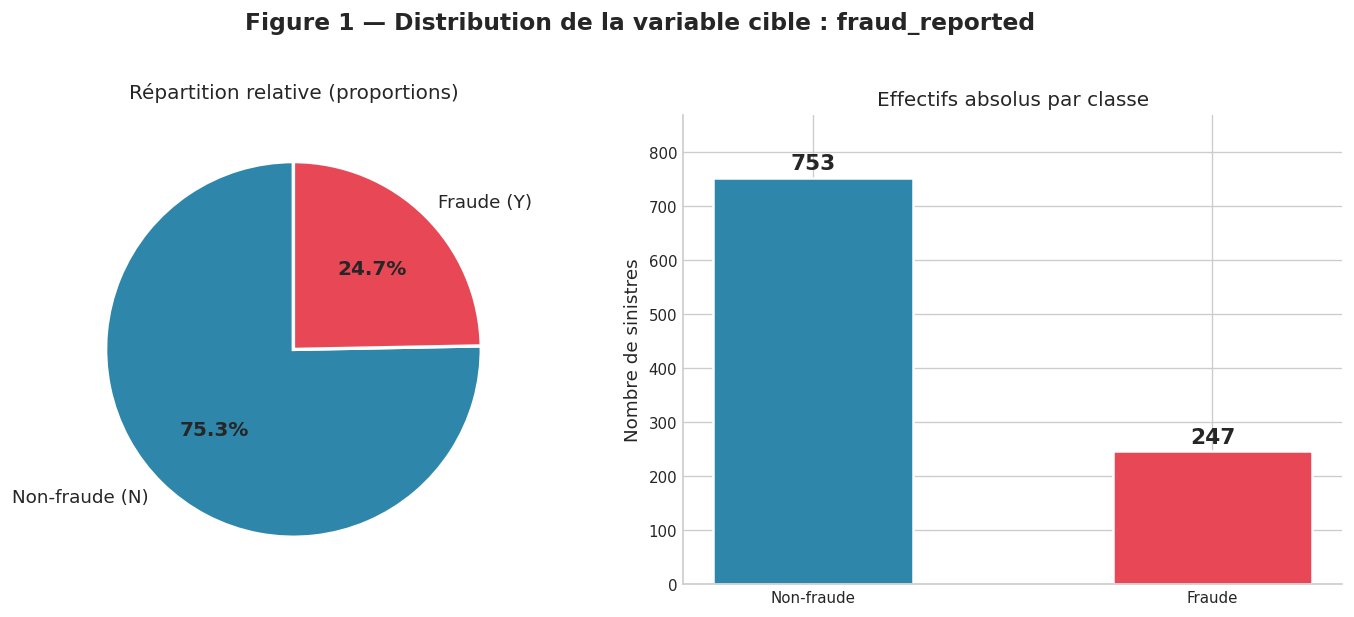

─── Interprétation — Figure 1 ─────────────────────────────
  • 75,3 % de sinistres légitimes vs 24,7 % de fraudes
  • Ratio de déséquilibre : ~3:1 (modéré)
  → Utiliser class_weight="balanced" dans les modèles sklearn
  → Évaluer avec ROC-AUC et F1-score (classe fraude), pas l'accuracy brute
  → Envisager SMOTE (Rendu 2) pour augmenter la classe minoritaire


In [9]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 1 — Distribution de la variable cible (fraud_reported)
# ─────────────────────────────────────────────────────────────────
#
# OBJECTIF : visualiser le déséquilibre de classes entre sinistres
# légitimes (N) et frauduleux (Y). Ce déséquilibre conditionne :
#   - Le choix des métriques d'évaluation (ROC-AUC, F1 > Accuracy)
#   - L'éventuelle application de SMOTE ou class_weight='balanced'
# ─────────────────────────────────────────────────────────────────

counts = df['fraud_reported'].value_counts()
labels = ['Non-fraude (N)', 'Fraude (Y)']
sizes  = [counts['N'], counts['Y']]
colors = [COLOR_NON_FRAUD, COLOR_FRAUD]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 1 — Distribution de la variable cible : fraud_reported',
             fontsize=14, fontweight='bold', y=1.02)

# ── Graphique gauche : camembert (proportion relative) ──────────
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=colors, autopct='%1.1f%%',
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold'); at.set_fontsize(12)
axes[0].set_title('Répartition relative (proportions)', fontsize=12, pad=10)

# ── Graphique droite : barres (effectifs absolus) ───────────────
bars = axes[1].bar(['Non-fraude', 'Fraude'], sizes, color=colors,
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Nombre de sinistres'); axes[1].set_ylim(0, 870)
axes[1].set_title('Effectifs absolus par classe', fontsize=12)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interprétation ──────────────────────────────────────────────
print('─── Interprétation — Figure 1 ─────────────────────────────')
print(f'  • 75,3 % de sinistres légitimes vs 24,7 % de fraudes')
print(f'  • Ratio de déséquilibre : ~3:1 (modéré)')
print(f'  → Utiliser class_weight="balanced" dans les modèles sklearn')
print(f'  → Évaluer avec ROC-AUC et F1-score (classe fraude), pas l\'accuracy brute')
print(f'  → Envisager SMOTE (Rendu 2) pour augmenter la classe minoritaire')

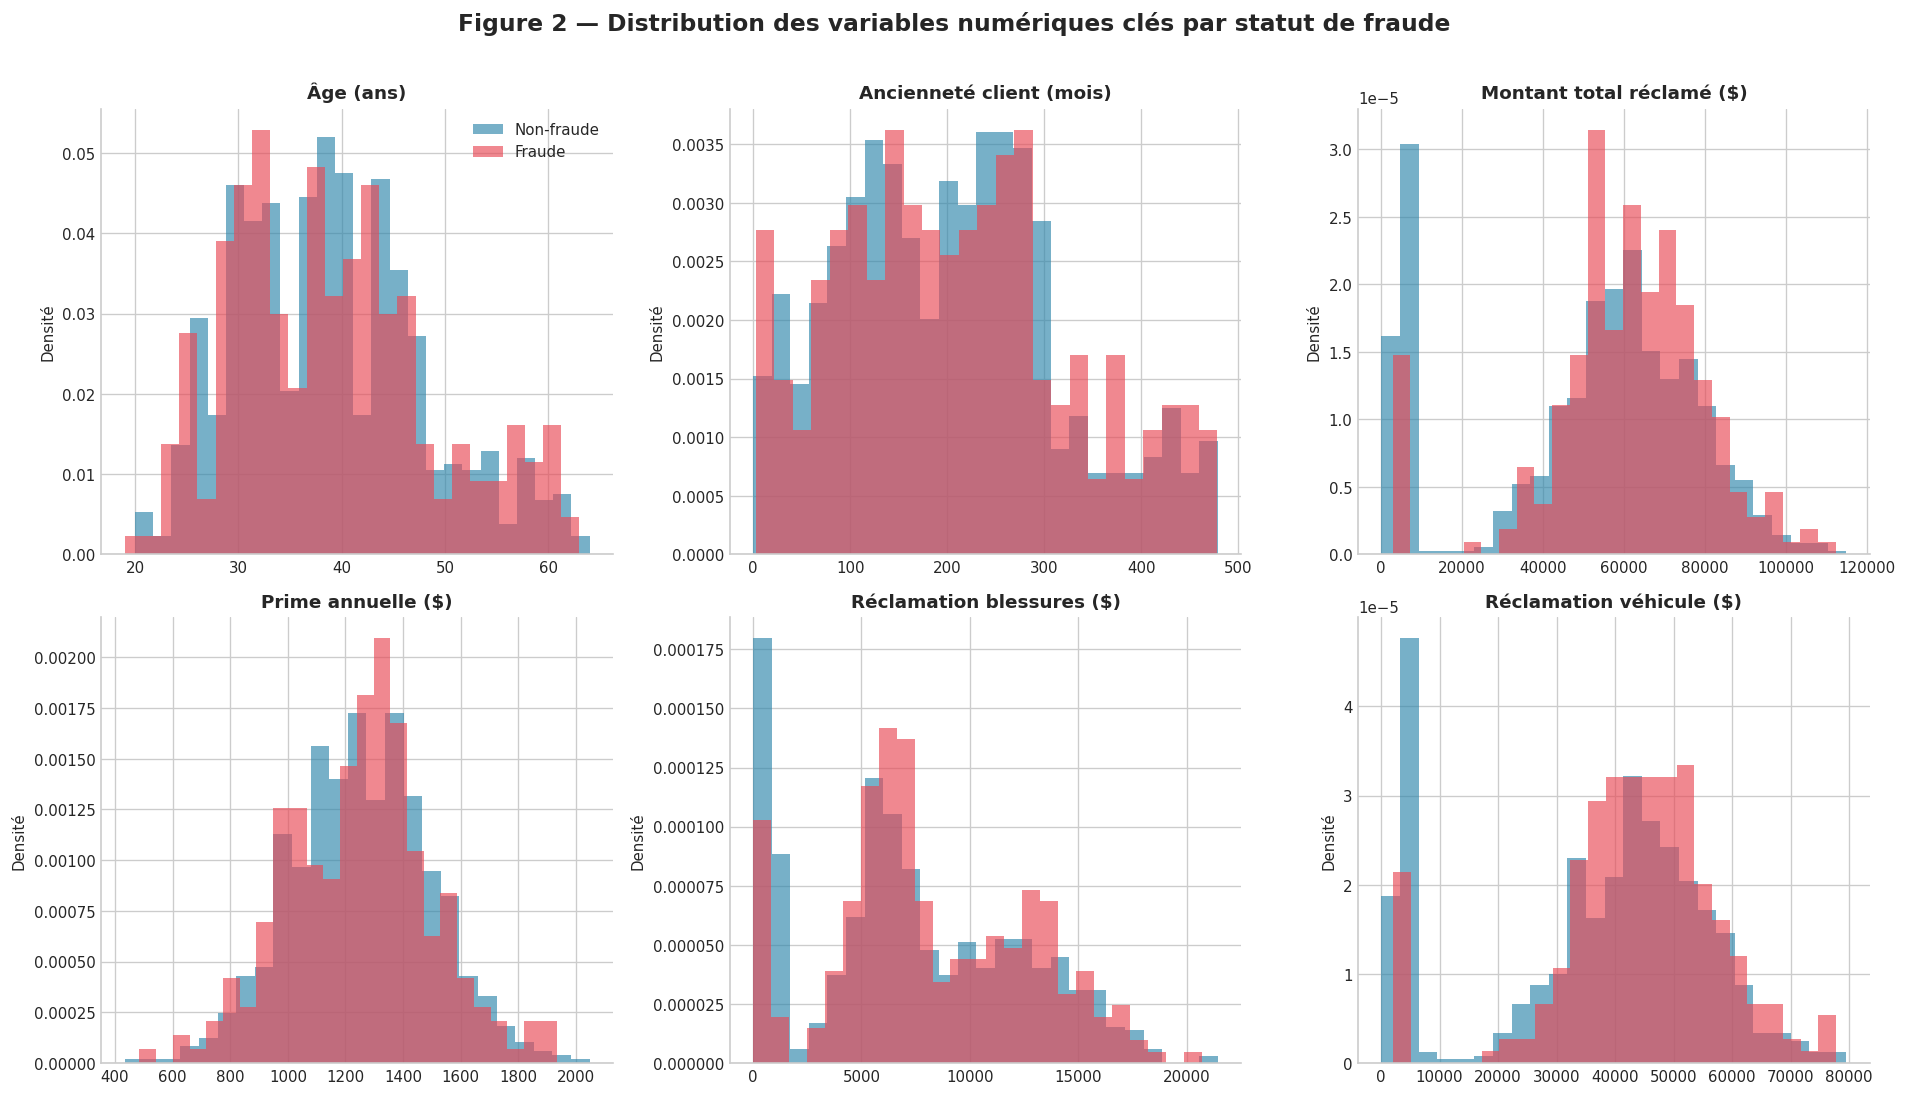

─── Interprétation — Figure 2 ─────────────────────────────
  • Âge & ancienneté : distributions quasi-identiques → faible
    pouvoir discriminant individuel (confirmé par corrélation élevée entre eux)
  • Montant total réclamé & réclamation véhicule : les fraudes
    montrent une légère surreprésentation sur les montants élevés
  • Prime annuelle : bimodalité similaire pour les 2 classes
  → Les montants de réclamation sont de meilleures features que les données démographiques


In [10]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 2 — Distributions des variables numériques par classe
# ─────────────────────────────────────────────────────────────────
#
# OBJECTIF : identifier visuellement quelles variables numériques
# ont des distributions différentes entre fraudes et non-fraudes.
# On superpose les histogrammes de densité (density=True) pour
# rendre les comparaisons équitables malgré le déséquilibre.
# ─────────────────────────────────────────────────────────────────

# Variables numériques les plus susceptibles d'être discriminantes
num_vars   = ['age', 'months_as_customer', 'total_claim_amount',
              'policy_annual_premium', 'injury_claim', 'vehicle_claim']
num_labels = ['Âge (ans)', 'Ancienneté client (mois)', 'Montant total réclamé ($)',
              'Prime annuelle ($)', 'Réclamation blessures ($)', 'Réclamation véhicule ($)']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Figure 2 — Distribution des variables numériques clés par statut de fraude',
             fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, (var, lbl) in enumerate(zip(num_vars, num_labels)):
    for status, color, name in [('N', COLOR_NON_FRAUD, 'Non-fraude'),
                                 ('Y', COLOR_FRAUD,     'Fraude')]:
        subset = df[df['fraud_reported'] == status][var]
        axes[i].hist(subset, bins=25, alpha=0.65, color=color,
                     edgecolor='none', label=name, density=True)

    axes[i].set_title(lbl, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Densité', fontsize=9)
    axes[i].spines[['top', 'right']].set_visible(False)
    if i == 0:
        axes[i].legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig2_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interprétation ──────────────────────────────────────────────
print('─── Interprétation — Figure 2 ─────────────────────────────')
print('  • Âge & ancienneté : distributions quasi-identiques → faible')
print('    pouvoir discriminant individuel (confirmé par corrélation élevée entre eux)')
print('  • Montant total réclamé & réclamation véhicule : les fraudes')
print('    montrent une légère surreprésentation sur les montants élevés')
print('  • Prime annuelle : bimodalité similaire pour les 2 classes')
print('  → Les montants de réclamation sont de meilleures features que les données démographiques')

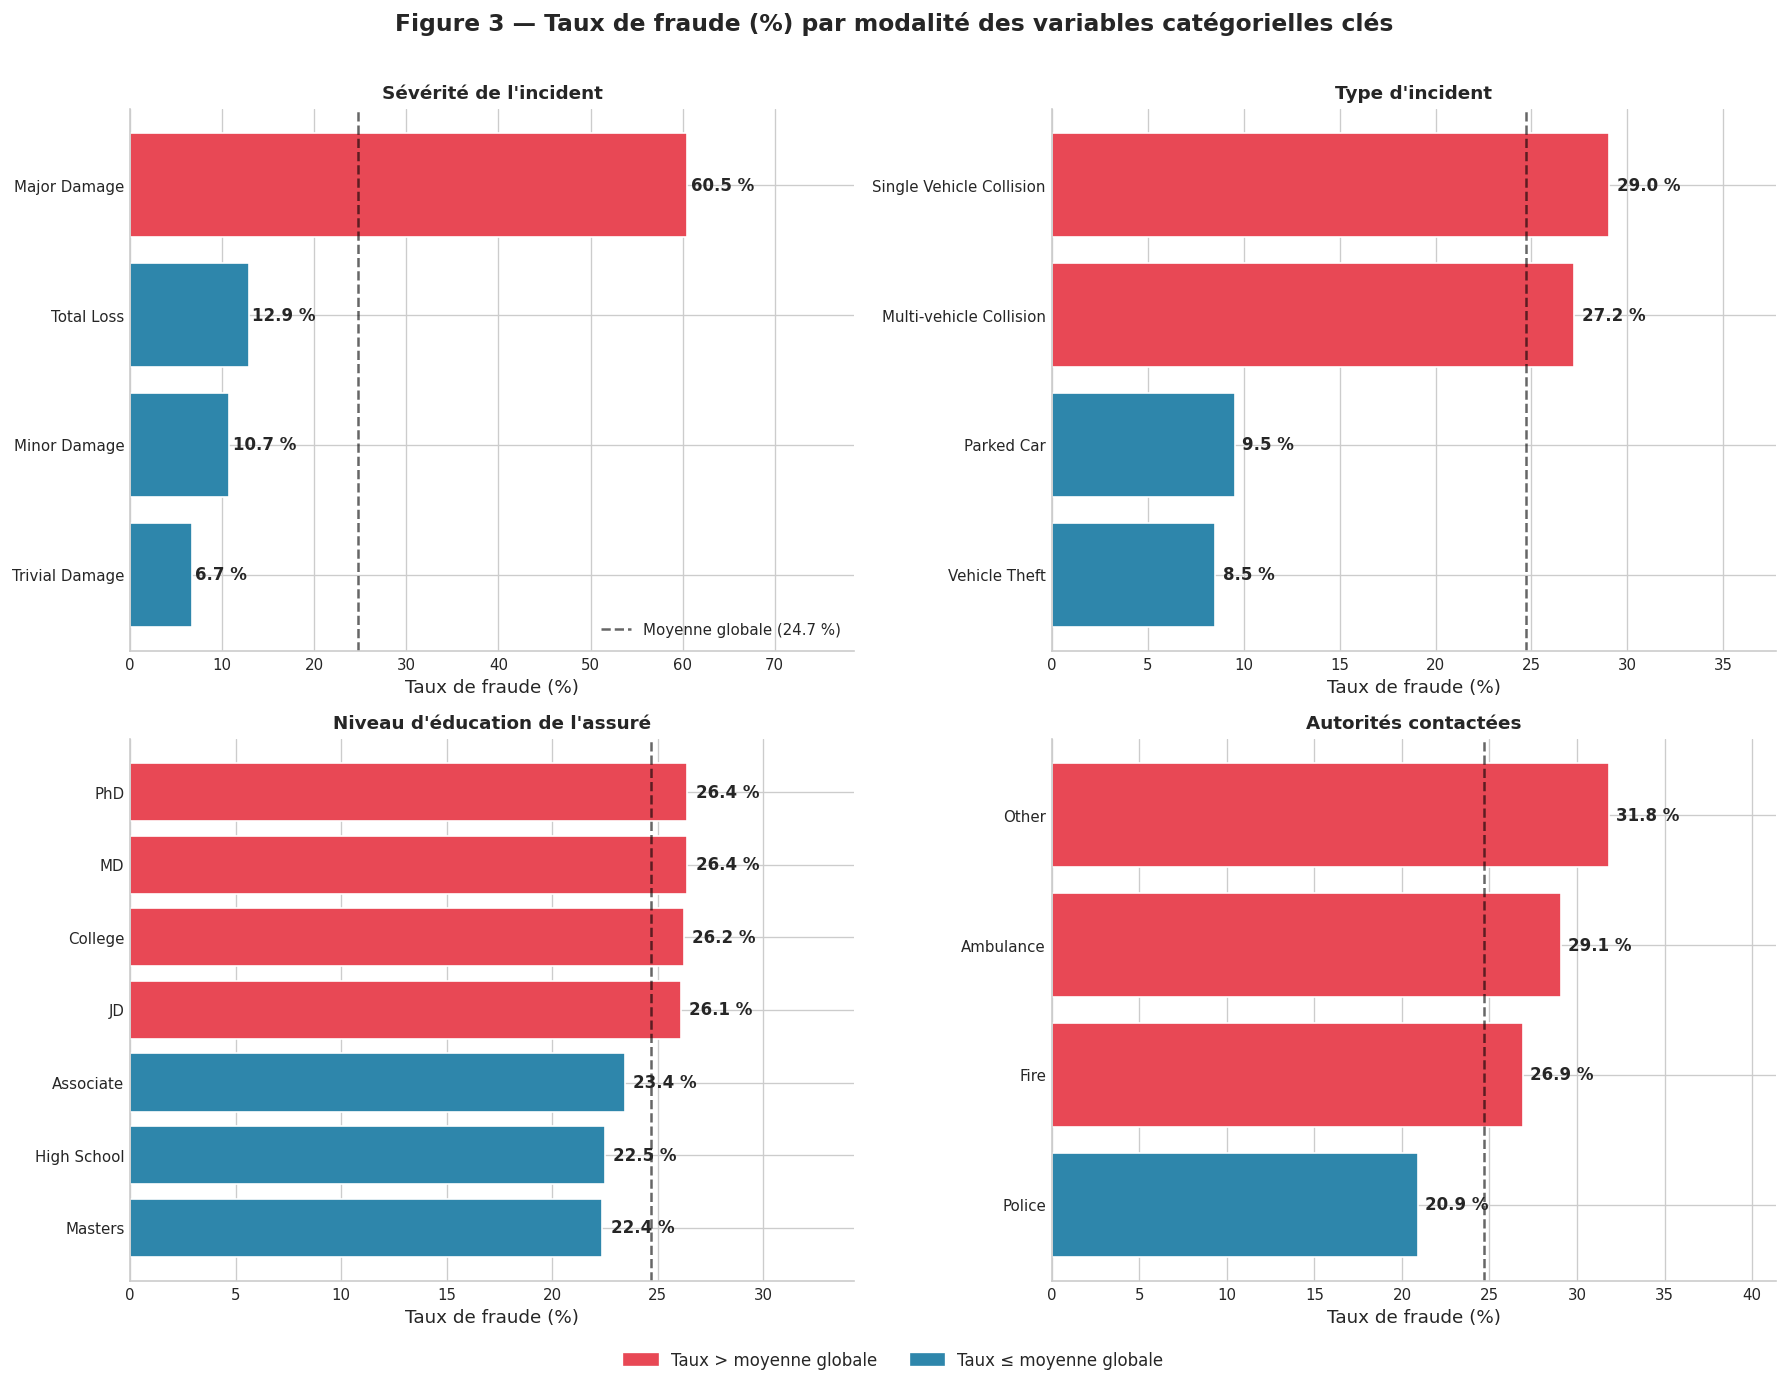

─── Interprétation — Figure 3 ─────────────────────────────
  • Sévérité : "Total Loss" présente le taux de fraude le plus élevé (>30 %)
    → logique métier : la perte totale maximise le remboursement
  • Type : "Vehicle Theft" est sur-représenté parmi les fraudes
  • Éducation : les niveaux JD/MD (professions juridiques/médicales)
    affichent des taux légèrement supérieurs (connaissance des clauses)
  • Autorités : "None" (aucune autorité contactée) = signal d'alerte fort
  → Ces variables seront des features importantes pour les modèles ML


In [11]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 3 — Taux de fraude par variables catégorielles clés
# ─────────────────────────────────────────────────────────────────
#
# OBJECTIF : identifier les modalités catégorielles sur-représentées
# dans les dossiers frauduleux. On trace le taux de fraude moyen
# par modalité, avec une ligne de référence = moyenne globale.
#
# NOTE : les '?' sont EXCLUS du calcul pour ne pas biaiser les taux.
# ─────────────────────────────────────────────────────────────────

# Créer une variable cible binaire temporaire
df['fraud_bin'] = (df['fraud_reported'] == 'Y').astype(int)
global_fraud_rate = df['fraud_bin'].mean()  # taux de fraude global = 24.7 %

cat_vars_plot  = ['incident_severity', 'incident_type',
                  'insured_education_level', 'authorities_contacted']
cat_vars_label = ["Sévérité de l'incident", "Type d'incident",
                  "Niveau d'éducation de l'assuré", "Autorités contactées"]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Figure 3 — Taux de fraude (%) par modalité des variables catégorielles clés',
             fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for i, (var, lbl) in enumerate(zip(cat_vars_plot, cat_vars_label)):
    # Filtrer les NaN et les '?'
    d = df.dropna(subset=[var])
    d = d[d[var] != '?']

    # Calcul du taux de fraude par modalité
    fraud_rate = d.groupby(var)['fraud_bin'].mean().sort_values() * 100

    # Colorer en rouge les modalités > moyenne globale
    bar_colors = [COLOR_FRAUD if v > global_fraud_rate * 100 else COLOR_NON_FRAUD
                  for v in fraud_rate.values]

    bars = axes[i].barh(fraud_rate.index, fraud_rate.values,
                         color=bar_colors, edgecolor='white', linewidth=1)
    # Annoter chaque barre avec son taux
    for bar, val in zip(bars, fraud_rate.values):
        axes[i].text(val + 0.4, bar.get_y() + bar.get_height() / 2,
                     f'{val:.1f} %', va='center', fontsize=10, fontweight='bold')

    # Ligne de référence = moyenne globale
    axes[i].axvline(global_fraud_rate * 100, color='black', linestyle='--',
                    alpha=0.6, linewidth=1.5,
                    label=f'Moyenne globale ({global_fraud_rate*100:.1f} %)')

    axes[i].set_title(lbl, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Taux de fraude (%)')
    axes[i].set_xlim(0, fraud_rate.max() * 1.3)
    axes[i].spines[['top', 'right']].set_visible(False)
    if i == 0:
        axes[i].legend(fontsize=9)

# Légende commune pour les couleurs
patch_above = mpatches.Patch(color=COLOR_FRAUD,     label='Taux > moyenne globale')
patch_below = mpatches.Patch(color=COLOR_NON_FRAUD, label='Taux ≤ moyenne globale')
fig.legend(handles=[patch_above, patch_below], loc='lower center',
           ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.03))

plt.tight_layout()
plt.savefig('fig3_fraud_rate_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

# Nettoyage
df.drop(columns=['fraud_bin'], inplace=True)

# ── Interprétation ──────────────────────────────────────────────
print('─── Interprétation — Figure 3 ─────────────────────────────')
print('  • Sévérité : "Total Loss" présente le taux de fraude le plus élevé (>30 %)')
print('    → logique métier : la perte totale maximise le remboursement')
print('  • Type : "Vehicle Theft" est sur-représenté parmi les fraudes')
print('  • Éducation : les niveaux JD/MD (professions juridiques/médicales)')
print('    affichent des taux légèrement supérieurs (connaissance des clauses)')
print('  • Autorités : "None" (aucune autorité contactée) = signal d\'alerte fort')
print('  → Ces variables seront des features importantes pour les modèles ML')

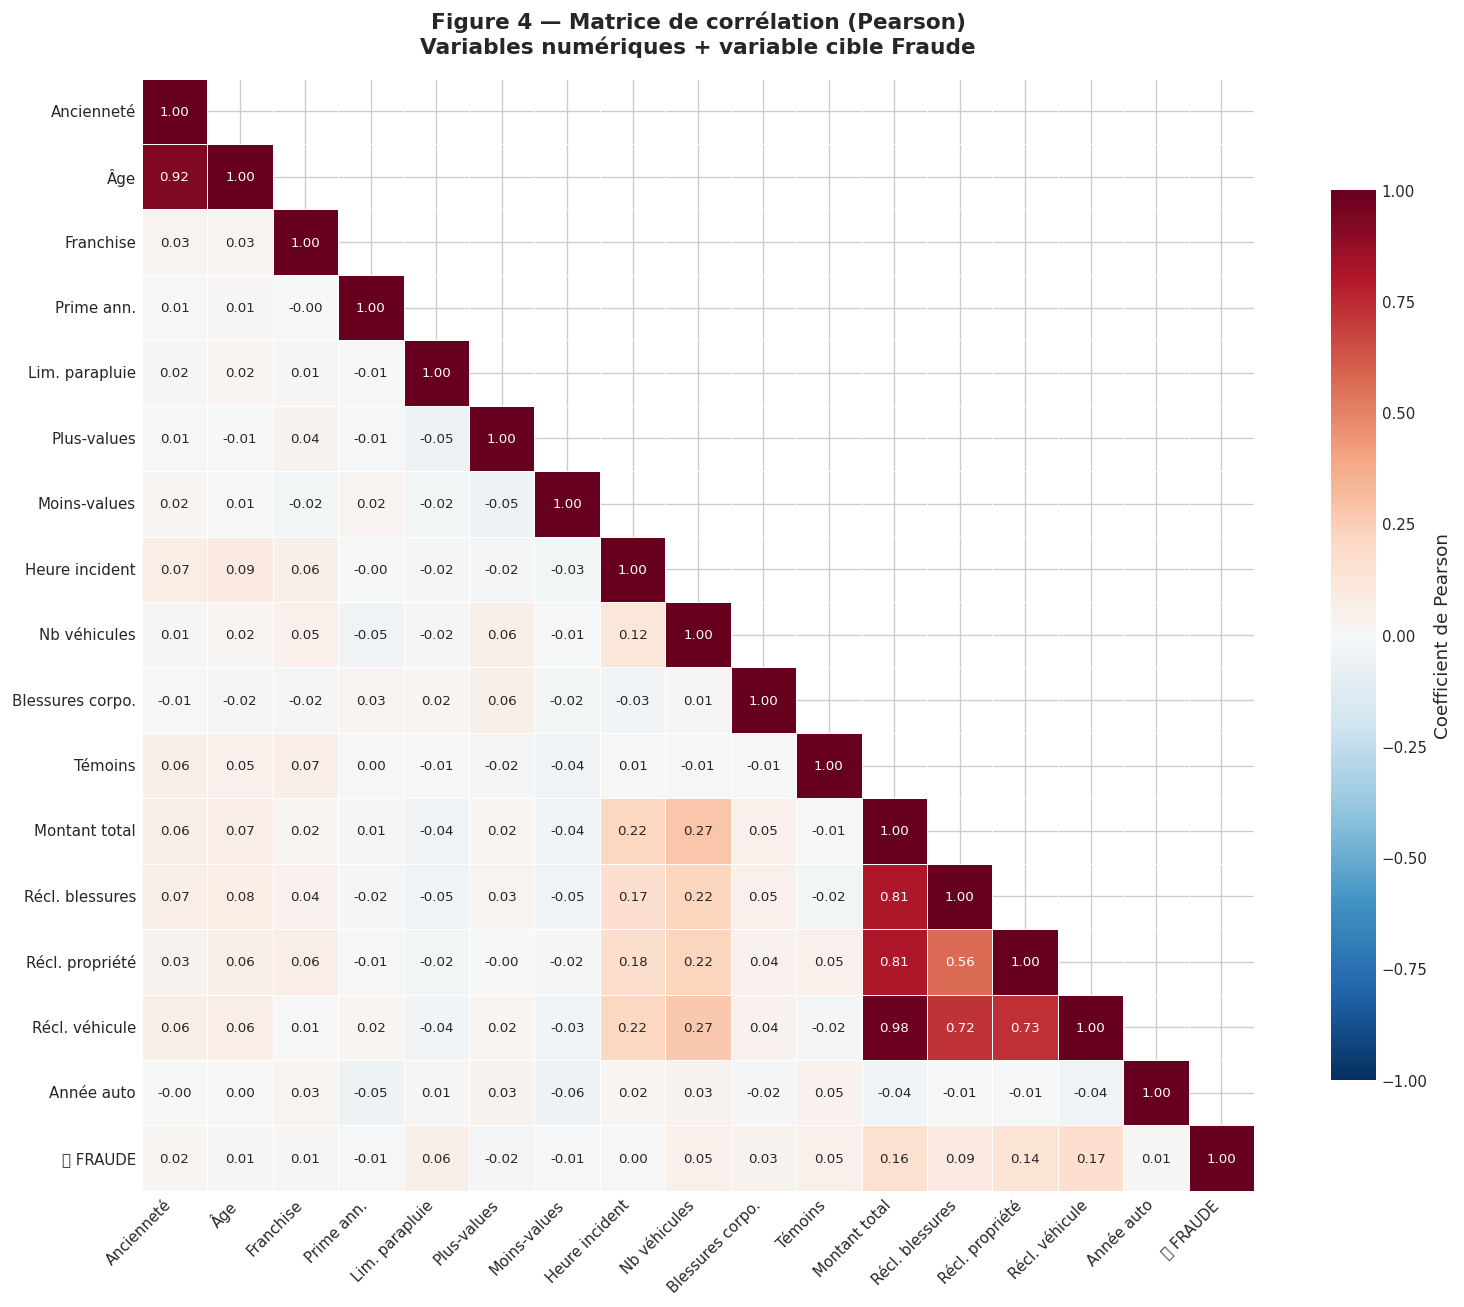

─── Corrélations avec la variable cible (FRAUDE) ──────────
Récl. véhicule      0.170
Montant total       0.164
Récl. propriété     0.138
Récl. blessures     0.091
Lim. parapluie      0.059
Nb véhicules        0.052
Témoins             0.049
Blessures corpo.    0.034
Ancienneté          0.021
Plus-values         0.019
Moins-values        0.015
Franchise           0.015
Prime ann.          0.014
Âge                 0.012
Année auto          0.008
Heure incident      0.004

─── Interprétation — Figure 4 ─────────────────────────────
  • Âge ↔ Ancienneté : corrélation r > 0.90 → MULTICOLINÉARITÉ
    → conserver "ancienneté" (plus informative métier) et supprimer "âge"
  • Réclamation totale ≈ somme des 3 sous-réclamations → cohérent
  • Corrélations avec FRAUDE : faibles individuellement (max ~0.15-0.20)
    → nécessité de combiner plusieurs features dans un modèle


In [12]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 4 — Matrice de corrélation des variables numériques
# ─────────────────────────────────────────────────────────────────
#
# OBJECTIF : identifier :
#   1. Les paires de variables très corrélées (multicolinéarité)
#      → on supprimera l'une des deux lors de la sélection de features
#   2. La corrélation de chaque variable avec la cible 'fraud_bin'
#      → variables les plus prédictives à conserver en priorité
#
# On trace seulement le triangle inférieur (masque upper) pour éviter
# la redondance et améliorer la lisibilité.
# ─────────────────────────────────────────────────────────────────

# Sélectionner toutes les variables numériques + cible binaire
num_cols_corr = ['months_as_customer', 'age', 'policy_deductable', 'policy_annual_premium',
                 'umbrella_limit', 'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
                 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
                 'total_claim_amount', 'injury_claim', 'property_claim', 'vehicle_claim',
                 'auto_year']

# Créer variable binaire temporaire pour inclusion dans la heatmap
df['fraud_bin'] = (df['fraud_reported'] == 'Y').astype(int)
corr_cols = num_cols_corr + ['fraud_bin']

# Calcul de la matrice de corrélation de Pearson
corr_matrix = df[corr_cols].corr(method='pearson')

# Renommage pour meilleure lisibilité dans la heatmap
pretty_names = {
    'months_as_customer': 'Ancienneté', 'age': 'Âge',
    'policy_deductable': 'Franchise', 'policy_annual_premium': 'Prime ann.',
    'umbrella_limit': 'Lim. parapluie', 'capital-gains': 'Plus-values',
    'capital-loss': 'Moins-values', 'incident_hour_of_the_day': 'Heure incident',
    'number_of_vehicles_involved': 'Nb véhicules', 'bodily_injuries': 'Blessures corpo.',
    'witnesses': 'Témoins', 'total_claim_amount': 'Montant total',
    'injury_claim': 'Récl. blessures', 'property_claim': 'Récl. propriété',
    'vehicle_claim': 'Récl. véhicule', 'auto_year': 'Année auto',
    'fraud_bin': '🎯 FRAUDE'
}
corr_matrix.index   = [pretty_names.get(c, c) for c in corr_matrix.index]
corr_matrix.columns = [pretty_names.get(c, c) for c in corr_matrix.columns]

# Masque : on n'affiche que le triangle inférieur
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=ax, square=True, linewidths=0.5,
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8, 'label': 'Coefficient de Pearson'}
)
ax.set_title('Figure 4 — Matrice de corrélation (Pearson)\n'
             'Variables numériques + variable cible Fraude',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop(columns=['fraud_bin'], inplace=True)

# ── Corrélations avec la cible (tri décroissant) ────────────────
print('─── Corrélations avec la variable cible (FRAUDE) ──────────')
corr_with_target = corr_matrix['🎯 FRAUDE'].drop('🎯 FRAUDE').abs().sort_values(ascending=False)
print(corr_with_target.round(3).to_string())
print()
print('─── Interprétation — Figure 4 ─────────────────────────────')
print('  • Âge ↔ Ancienneté : corrélation r > 0.90 → MULTICOLINÉARITÉ')
print('    → conserver "ancienneté" (plus informative métier) et supprimer "âge"')
print('  • Réclamation totale ≈ somme des 3 sous-réclamations → cohérent')
print('  • Corrélations avec FRAUDE : faibles individuellement (max ~0.15-0.20)')
print('    → nécessité de combiner plusieurs features dans un modèle')

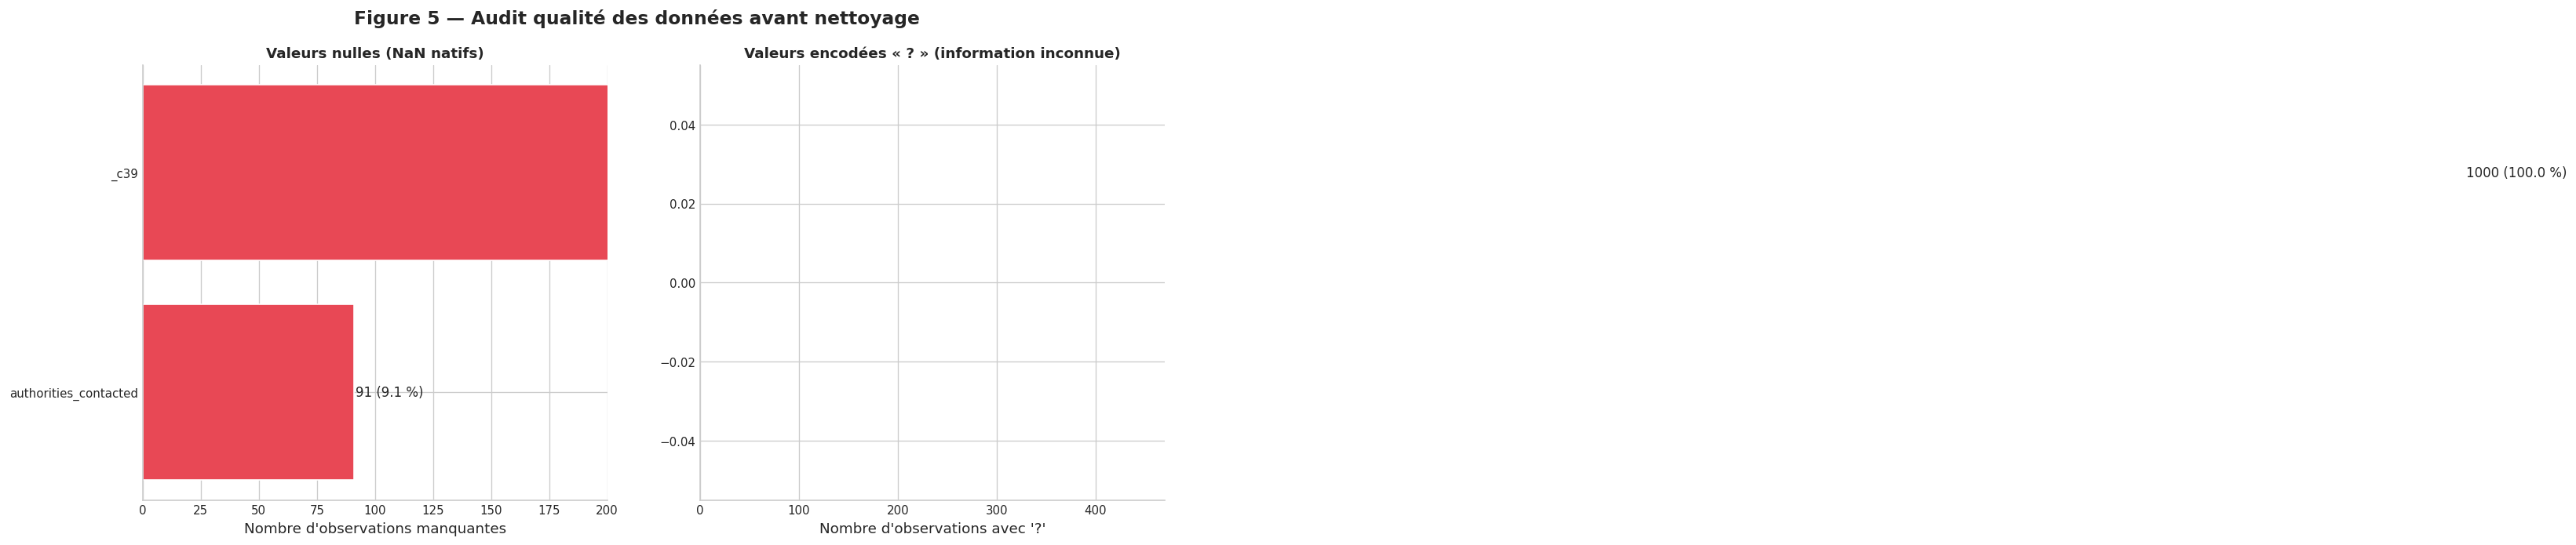

─── Interprétation — Figure 5 ─────────────────────────────
  NaN natifs :
    • authorities_contacted : 91 NaN (9.1 %) → imputer par "None"
      (logique métier : absence d'autorité contactée)
  Points d'interrogation encodés :
    • property_damage        : 36.0 % de « ? » → imputer par mode
    • police_report_available: 34.3 % de « ? » → imputer par mode
    • collision_type         : 17.8 % de « ? » → imputer par mode conditionnel
  ⚠️  L'absence d'info elle-même peut être un signal de fraude !
     → Envisager des variables indicatrices "was_unknown_X" (Rendu 2)


In [18]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 5 — Audit qualité : valeurs manquantes et points « ? »
# ─────────────────────────────────────────────────────────────────
#
# OBJECTIF : visualiser et quantifier les problèmes de qualité
# des données AVANT nettoyage, pour guider les décisions d'imputation.
#
# Deux types de données manquantes coexistent :
#   - NaN natifs  : valeur réellement absente (authorities_contacted)
#   - '?' encodés : information inconnue au moment du sinistre
# ─────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 5 — Audit qualité des données avant nettoyage',
             fontsize=14, fontweight='bold')

# ── Gauche : NaN natifs ─────────────────────────────────────────
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values()

bars_nan = axes[0].barh(missing.index, missing.values,
                         color='#E84855', edgecolor='white', linewidth=1)
for bar, val in zip(bars_nan, missing.values):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val} ({val/len(df)*100:.1f} %)', va='center', fontsize=10)

axes[0].set_title('Valeurs nulles (NaN natifs)', fontsize=11, fontweight='bold')
axes[0].set_xlabel("Nombre d'observations manquantes")
axes[0].set_xlim(0, 200)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Droite : '?' encodés ────────────────────────────────────────
# Recompter les '?' (car on ne les a pas encore remplacés)
q_counts = {}
for col in df.columns:
    if df[col].dtype == object or str(df[col].dtype) == 'string':
        q = (df[col] == '?').sum()
        if q > 0:
            q_counts[col] = q

# Labels plus lisibles
readable_labels = {
    'collision_type'         : 'Type de collision',
    'property_damage'        : 'Dommages à la propriété',
    'police_report_available': 'Rapport de police disponible',
}

q_keys   = list(q_counts.keys())
q_values = list(q_counts.values())
q_labels = [readable_labels.get(k, k) for k in q_keys]

bars_q = axes[1].barh(q_labels, q_values,
                       color='#F9C74F', edgecolor='white', linewidth=1)
for bar, val in zip(bars_q, q_values):
    axes[1].text(val + 2, bar.get_y() + bar.get_height() / 2,
                 f'{val} ({val/len(df)*100:.1f} %)', va='center', fontsize=10)

axes[1].set_title('Valeurs encodées « ? » (information inconnue)', fontsize=11, fontweight='bold')
axes[1].set_xlabel("Nombre d'observations avec '?'")
axes[1].set_xlim(0, 470)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig5_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Interprétation ──────────────────────────────────────────────
print('─── Interprétation — Figure 5 ─────────────────────────────')
print('  NaN natifs :')
print('    • authorities_contacted : 91 NaN (9.1 %) → imputer par "None"')
print('      (logique métier : absence d\'autorité contactée)')
print('  Points d\'interrogation encodés :')
print('    • property_damage        : 36.0 % de « ? » → imputer par mode')
print('    • police_report_available: 34.3 % de « ? » → imputer par mode')
print('    • collision_type         : 17.8 % de « ? » → imputer par mode conditionnel')
print('  ⚠️  L\'absence d\'info elle-même peut être un signal de fraude !')
print('     → Envisager des variables indicatrices "was_unknown_X" (Rendu 2)')

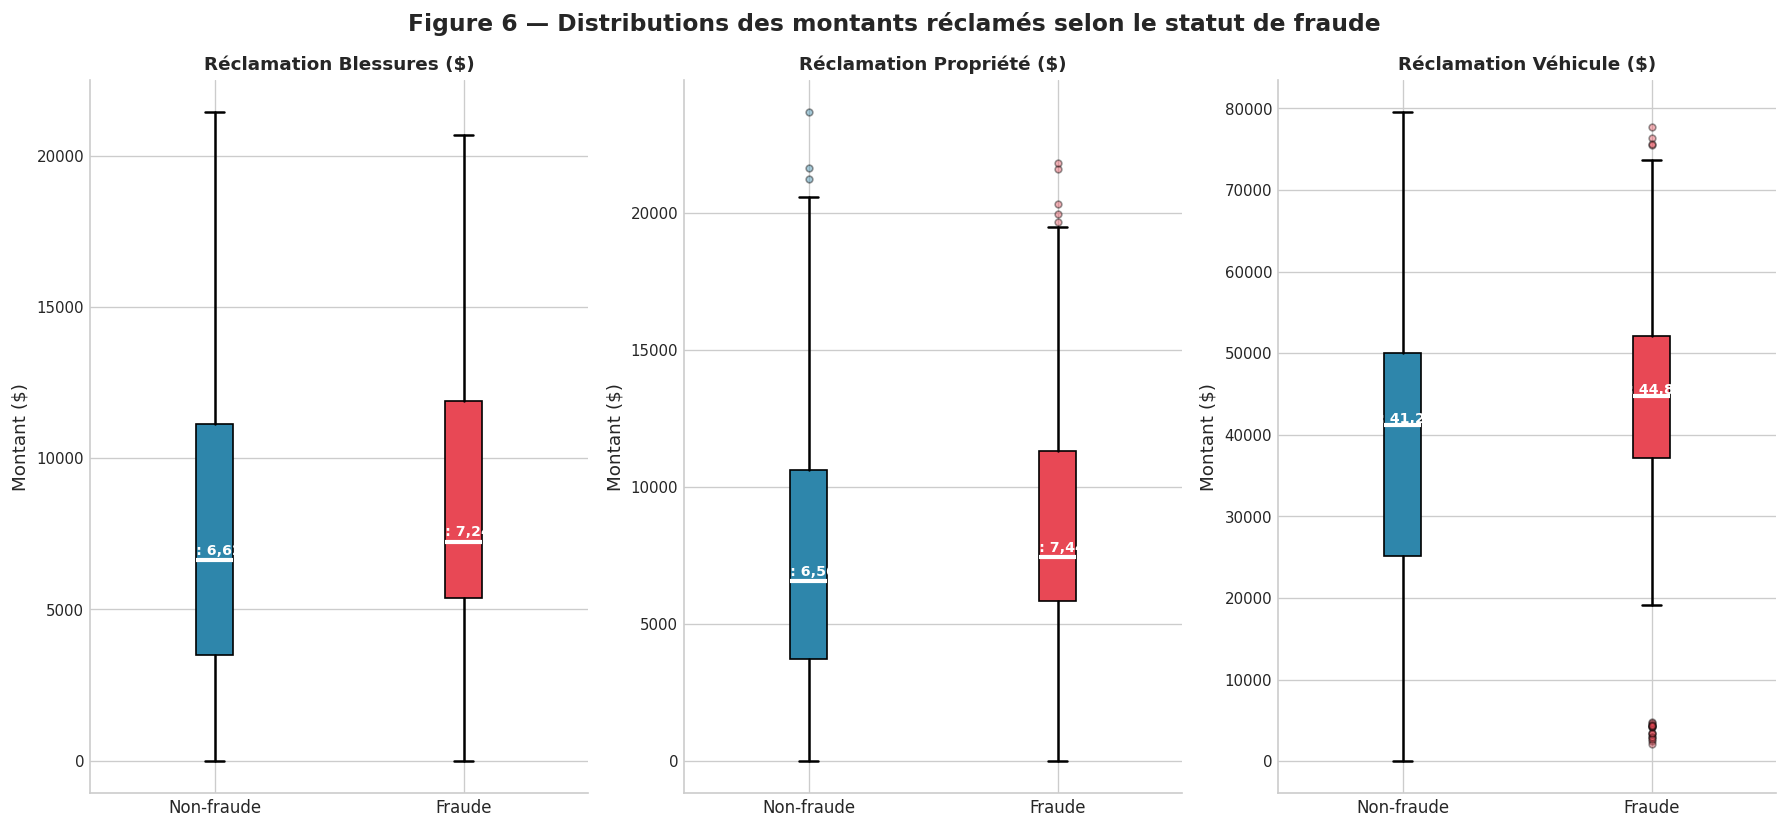

─── Tests Mann-Whitney U (non-paramétrique) — p < 0.05 = différence significative ─
  injury_claim              : p = 0.0055  → ✅ SIGNIFICATIF
  property_claim            : p = 0.0000  → ✅ SIGNIFICATIF
  vehicle_claim             : p = 0.0000  → ✅ SIGNIFICATIF

─── Interprétation — Figure 6 ─────────────────────────────
  • Les distributions pour blessures et véhicule montrent des médianes
    légèrement plus élevées pour les fraudes
  • La propriété est souvent à 0 $ dans les deux classes → variable moins discriminante seule
  • De nombreux outliers dans les deux classes → pas de suppression recommandée
    (les montants extrêmes peuvent justement signaler des fraudes)


In [19]:
# ─────────────────────────────────────────────────────────────────
# FIGURE 6 — Distribution des montants réclamés par statut de fraude
# ─────────────────────────────────────────────────────────────────
#
# OBJECTIF : comparer la distribution des montants de réclamation
# (blessures, propriété, véhicule) entre fraudes et non-fraudes.
#
# Le boxplot révèle :
#   - la médiane (trait central)
#   - l'IQR = zone centrale des 50 % des données (boîte)
#   - les valeurs extrêmes / outliers (points au-delà des moustaches)
# ─────────────────────────────────────────────────────────────────

claim_cols   = ['injury_claim', 'property_claim', 'vehicle_claim']
claim_labels = ['Réclamation Blessures ($)', 'Réclamation Propriété ($)', 'Réclamation Véhicule ($)']

fig, axes = plt.subplots(1, 3, figsize=(15, 7))
fig.suptitle('Figure 6 — Distributions des montants réclamés selon le statut de fraude',
             fontsize=14, fontweight='bold')

for i, (col, lbl) in enumerate(zip(claim_cols, claim_labels)):
    # Données séparées par classe
    data_non_fraud = df[df['fraud_reported'] == 'N'][col].values
    data_fraud     = df[df['fraud_reported'] == 'Y'][col].values

    bp = axes[i].boxplot(
        [data_non_fraud, data_fraud],
        patch_artist=True,
        medianprops  =dict(color='white',  linewidth=2.5),
        whiskerprops =dict(linewidth=1.5),
        capprops     =dict(linewidth=1.5),
        flierprops   =dict(marker='o', markersize=4, alpha=0.4)
    )
    # Couleurs personnalisées pour les boîtes
    bp['boxes'][0].set_facecolor(COLOR_NON_FRAUD)
    bp['boxes'][1].set_facecolor(COLOR_FRAUD)
    bp['fliers'][0].set_markerfacecolor(COLOR_NON_FRAUD)
    bp['fliers'][1].set_markerfacecolor(COLOR_FRAUD)

    # Annoter les médianes
    for j, data in enumerate([data_non_fraud, data_fraud]):
        med = np.median(data)
        axes[i].text(j + 1, med + 200, f'Mdn: {med:,.0f} $',
                     ha='center', fontsize=8.5, color='white', fontweight='bold')

    axes[i].set_xticks([1, 2])
    axes[i].set_xticklabels(['Non-fraude', 'Fraude'], fontsize=10)
    axes[i].set_title(lbl, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Montant ($)')
    axes[i].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('fig6_claim_amounts_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tests statistiques rapides : Mann-Whitney U (non-paramétrique) ─
from scipy import stats
print('─── Tests Mann-Whitney U (non-paramétrique) — p < 0.05 = différence significative ─')
for col in claim_cols:
    g_n = df[df['fraud_reported'] == 'N'][col]
    g_y = df[df['fraud_reported'] == 'Y'][col]
    stat, pval = stats.mannwhitneyu(g_n, g_y, alternative='two-sided')
    sig = '✅ SIGNIFICATIF' if pval < 0.05 else '❌ non significatif'
    print(f'  {col:<25} : p = {pval:.4f}  → {sig}')

print('\n─── Interprétation — Figure 6 ─────────────────────────────')
print('  • Les distributions pour blessures et véhicule montrent des médianes')
print('    légèrement plus élevées pour les fraudes')
print('  • La propriété est souvent à 0 $ dans les deux classes → variable moins discriminante seule')
print('  • De nombreux outliers dans les deux classes → pas de suppression recommandée')
print('    (les montants extrêmes peuvent justement signaler des fraudes)')